# 06 - Ablation: Target Selection
Ablation study comparing removed-part-aware vs largest-hole-only
target selection under the same planar triangulation backend.

In [2]:
import sys, os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import load_config, ensure_dirs
from src.data.dataset_index import DatasetIndex
from src.data.sample_loader import SampleLoader
from src.geometry.boundary import extract_boundary_loops
from src.target_selection.selectors import select_target_loops_by_bbox, select_largest_loop
from src.repair.planar_patch import planar_triangulation_repair
from src.evaluation.evaluator import Evaluator
from tqdm import tqdm

In [3]:
cfg = load_config(os.path.join(PROJECT_ROOT, 'configs', 'chair_leg.yaml'))
ensure_dirs(cfg)
index = DatasetIndex(cfg['paths']['raw_data_dir'])
loader = SampleLoader(cfg['paths']['raw_data_dir'])
margin = cfg['repair']['margin']
prox_thresh = cfg['repair']['proximity_threshold']
evaluator = Evaluator(margin=margin, proximity_threshold=prox_thresh)

In [4]:
# Run ablation
rpa_results = []
lh_results = []

for sid in tqdm(index.sample_ids, desc="Ablation"):
    try:
        sample = loader.load(sid)
        damaged = sample['damaged_mesh']
        removed = sample['removed_part_mesh']
        loops = extract_boundary_loops(damaged)
        if not loops:
            continue

        # RPA targets
        targets_rpa = select_target_loops_by_bbox(damaged, loops, removed, margin, prox_thresh)
        result_rpa = planar_triangulation_repair(damaged, targets_rpa)
        metrics_rpa = evaluator.evaluate(damaged, result_rpa['repaired_mesh'],
                                        removed, result_rpa, targets_rpa)
        metrics_rpa['sample_id'] = sid
        rpa_results.append(metrics_rpa)

        # LH targets
        targets_lh = select_largest_loop(damaged, loops)
        result_lh = planar_triangulation_repair(damaged, targets_lh)
        metrics_lh = evaluator.evaluate(damaged, result_lh['repaired_mesh'],
                                       removed, result_lh, targets_rpa)
        metrics_lh['sample_id'] = sid
        lh_results.append(metrics_lh)

    except Exception as e:
        print(f"  Error on {sid}: {e}")

df_rpa = pd.DataFrame(rpa_results)
df_lh = pd.DataFrame(lh_results)

Ablation: 100%|██████████████████████████████████████████████████████████████████████| 100/100 [04:56<00:00,  2.97s/it]


In [5]:
# Compare key metrics
metrics_to_compare = [
    ('target_loop_length_after', 'Residual Target Loop Length', True),
    ('improvement', 'Improvement', False),
    ('locality_ratio', 'Locality Ratio', False),
    ('avg_new_face_quality', 'Avg Triangle Quality', False),
]

print(f"{'Metric':<35} {'RPA Mean':>12} {'LH Mean':>12} {'Delta':>12}")
print("-" * 75)
for col, name, lower_better in metrics_to_compare:
    rpa_mean = df_rpa[col].mean()
    lh_mean = df_lh[col].mean()
    delta = rpa_mean - lh_mean
    marker = '(better)' if (delta < 0 and lower_better) or (delta > 0 and not lower_better) else ''
    print(f"{name:<35} {rpa_mean:>12.4f} {lh_mean:>12.4f} {delta:>+12.4f} {marker}")

Metric                                  RPA Mean      LH Mean        Delta
---------------------------------------------------------------------------
Residual Target Loop Length               1.9384      38.2569     -36.3185 (better)
Improvement                              38.0133       1.6948     +36.3185 (better)
Locality Ratio                            0.6710       0.5717      +0.0993 (better)
Avg Triangle Quality                      0.4341       0.4122      +0.0220 (better)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_24080\1725597908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['RPA', 'LH-Only'], patch_artist=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_24080\1725597908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['RPA', 'LH-Only'], patch_artist=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_24080\1725597908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['RPA', 'LH-Only'], patch_artist=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_24080\

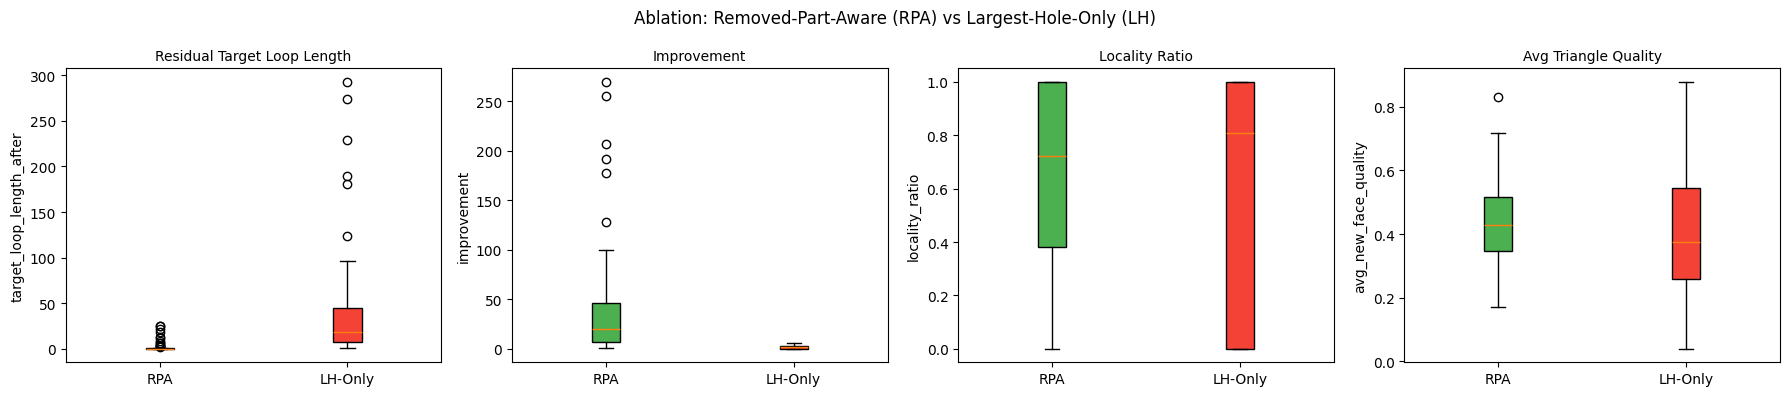

In [6]:
# Visualize ablation results
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (col, title, lower_better) in zip(axes, metrics_to_compare):
    data = [df_rpa[col].values, df_lh[col].values]
    bp = ax.boxplot(data, labels=['RPA', 'LH-Only'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#4CAF50')
    bp['boxes'][1].set_facecolor('#F44336')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(col)

plt.suptitle('Ablation: Removed-Part-Aware (RPA) vs Largest-Hole-Only (LH)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['figures_dir'], 'ablation_target_selection.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

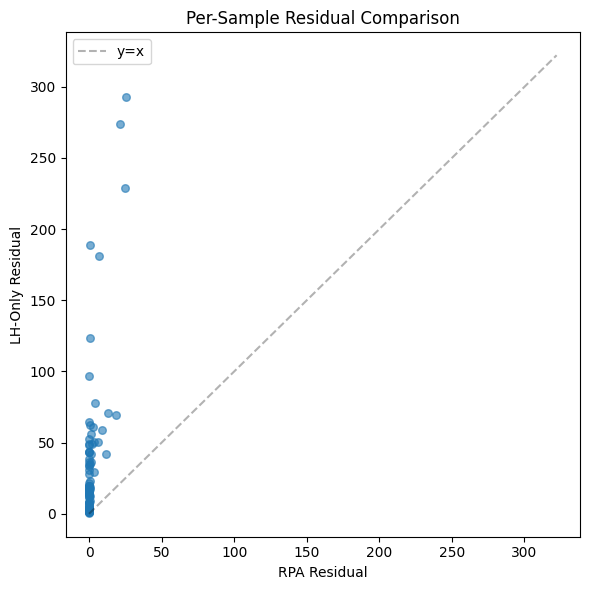

In [7]:
# Per-sample scatter: RPA residual vs LH residual
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_rpa['target_loop_length_after'], df_lh['target_loop_length_after'],
           alpha=0.6, s=30)
lim = max(df_rpa['target_loop_length_after'].max(), df_lh['target_loop_length_after'].max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='y=x')
ax.set_xlabel('RPA Residual')
ax.set_ylabel('LH-Only Residual')
ax.set_title('Per-Sample Residual Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['figures_dir'], 'ablation_scatter.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()